# 🤖 Machine Learning Modeling

## Buyer Segmentation using Clustering Algorithms

### Objectives

- Load Final Buyer Dataset
- Validate Features
- Encode Categorical Variables
- Scale Numerical Features
- Determine Optimal Number of Clusters
- Train K-Means Model
- Train Hierarchical Clustering Model
- Compare Results

In [1]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
# ============================================
# Load Final Dataset
# ============================================

buyer_df = pd.read_csv("../data/processed/final_buyer_dataset.csv")

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


In [3]:
buyer_df.shape

(2000, 17)

In [4]:
buyer_df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_properties,total_investment,avg_property_price,avg_property_area
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154


In [5]:
buyer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            2000 non-null   str    
 1   client_type          2000 non-null   str    
 2   first_name           2000 non-null   str    
 3   last_name            2000 non-null   str    
 4   date_of_birth        2000 non-null   str    
 5   gender               2000 non-null   str    
 6   country              2000 non-null   str    
 7   region               2000 non-null   str    
 8   acquisition_purpose  2000 non-null   str    
 9   satisfaction_score   2000 non-null   int64  
 10  loan_applied         2000 non-null   str    
 11  referral_channel     2000 non-null   str    
 12  age                  2000 non-null   int64  
 13  total_properties     2000 non-null   int64  
 14  total_investment     2000 non-null   float64
 15  avg_property_price   2000 non-null   float64
 16 

In [6]:
# ============================================
# Create Modeling Dataset
# ============================================

model_df = buyer_df.drop(
    columns=[
        "client_id",
        "first_name",
        "last_name",
        "date_of_birth"
    ]
)

model_df.head()

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_properties,total_investment,avg_property_price,avg_property_area
0,Individual,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000
1,Individual,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000
2,Individual,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000
3,Individual,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333
4,Company,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154


In [7]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_type          2000 non-null   str    
 1   gender               2000 non-null   str    
 2   country              2000 non-null   str    
 3   region               2000 non-null   str    
 4   acquisition_purpose  2000 non-null   str    
 5   satisfaction_score   2000 non-null   int64  
 6   loan_applied         2000 non-null   str    
 7   referral_channel     2000 non-null   str    
 8   age                  2000 non-null   int64  
 9   total_properties     2000 non-null   int64  
 10  total_investment     2000 non-null   float64
 11  avg_property_price   2000 non-null   float64
 12  avg_property_area    2000 non-null   float64
dtypes: float64(3), int64(3), str(7)
memory usage: 276.9 KB


In [8]:
# ============================================
# Check Unique Values of Categorical Columns
# ============================================

categorical_cols = model_df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 50)
    print(f"{col}")
    print(model_df[col].value_counts())
    print()

client_type
client_type
Individual    1897
Company        103
Name: count, dtype: int64

gender
gender
M    1012
F     988
Name: count, dtype: int64

country
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

region
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Northern Ireland           24
Ohio                       24
British Columbia           20
Wales                      17
Hamburg                    16
Flanders     

C:\Users\anura\AppData\Local\Temp\ipykernel_6016\991190948.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(include="object").columns


In [9]:
categorical_cols = model_df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 50)
    print(f"{col}")
    print(model_df[col].value_counts())
    print()

client_type
client_type
Individual    1897
Company        103
Name: count, dtype: int64

gender
gender
M    1012
F     988
Name: count, dtype: int64

country
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

region
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Northern Ireland           24
Ohio                       24
British Columbia           20
Wales                      17
Hamburg                    16
Flanders     

C:\Users\anura\AppData\Local\Temp\ipykernel_6016\2768748825.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(include="object").columns


In [10]:
# Show unique values count for each categorical column

for col in categorical_cols:
    print(f"{col}: {model_df[col].nunique()} unique values")

client_type: 2 unique values
gender: 2 unique values
country: 10 unique values
region: 57 unique values
acquisition_purpose: 2 unique values
loan_applied: 2 unique values
referral_channel: 3 unique values


In [11]:
# ============================================
# Label Encoding for Binary Features
# ============================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

binary_columns = [
    "client_type",
    "gender",
    "acquisition_purpose",
    "loan_applied"
]

for col in binary_columns:
    model_df[col] = label_encoder.fit_transform(model_df[col])

print("Binary columns encoded successfully.")

Binary columns encoded successfully.


In [12]:
model_df.head()

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_properties,total_investment,avg_property_price,avg_property_area
0,1,0,USA,California,0,4,1,Website,58,4,1246764.72,311691.180000,983.885000
1,1,1,USA,California,0,1,0,Website,63,5,1841095.93,368219.186000,1187.942000
2,1,1,USA,California,0,4,1,Agency,67,5,1661457.59,332291.518000,1058.110000
3,1,1,USA,California,0,5,0,Website,66,6,1608263.51,268043.918333,937.103333
4,0,1,USA,California,1,5,0,Website,50,13,3653385.38,281029.644615,927.296154


In [13]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_type          2000 non-null   int64  
 1   gender               2000 non-null   int64  
 2   country              2000 non-null   str    
 3   region               2000 non-null   str    
 4   acquisition_purpose  2000 non-null   int64  
 5   satisfaction_score   2000 non-null   int64  
 6   loan_applied         2000 non-null   int64  
 7   referral_channel     2000 non-null   str    
 8   age                  2000 non-null   int64  
 9   total_properties     2000 non-null   int64  
 10  total_investment     2000 non-null   float64
 11  avg_property_price   2000 non-null   float64
 12  avg_property_area    2000 non-null   float64
dtypes: float64(3), int64(7), str(3)
memory usage: 239.7 KB


In [14]:
# ============================================
# Columns for One-Hot Encoding
# ============================================

one_hot_columns = [
    "country",
    "region",
    "referral_channel"
]

print("Columns selected for One-Hot Encoding:")
print(one_hot_columns)

Columns selected for One-Hot Encoding:
['country', 'region', 'referral_channel']


In [15]:
# ============================================
# Apply One-Hot Encoding
# ============================================

model_df = pd.get_dummies(
    model_df,
    columns=one_hot_columns,
    drop_first=True,
    dtype=int
)

print("One-Hot Encoding Completed Successfully.")

One-Hot Encoding Completed Successfully.


In [16]:
model_df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,age,total_properties,total_investment,avg_property_price,avg_property_area,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA,region_Arizona,region_Baja California,region_Bavaria,region_Berlin,region_British Columbia,region_Brittany,region_Brussels,region_California,region_Capital Region,region_Central Denmark,region_Colorado,region_England,region_Flanders,region_Florida,region_Georgia,region_Hamburg,region_Hesse,region_Ile-de-France,region_Jalisco,region_Kansas,region_Krasnodar Krai,region_Manitoba,region_Mexico City,region_Moscow Oblast,region_Nevada,region_New South Wales,region_New York,region_Normandy,region_North Denmark,region_North Rhine-Westphalia,region_Northern Ireland,region_Novosibirsk,region_Nuevo Leon,region_Occitanie,region_Ohio,region_Ontario,region_Oregon,region_Provence,region_Puebla,region_Quebec,region_Queensland,region_Saint Petersburg,region_Scotland,region_South Australia,region_Southern Denmark,region_Tatarstan,region_Texas,region_Utah,region_Victoria,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Client,referral_channel_Website
0,1,0,0,4,1,58,4,1246764.72,311691.180000,983.885000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1,1,0,1,0,63,5,1841095.93,368219.186000,1187.942000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,1,1,0,4,1,67,5,1661457.59,332291.518000,1058.110000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,1,0,5,0,66,6,1608263.51,268043.918333,937.103333,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,1,1,5,0,50,13,3653385.38,281029.644615,927.296154,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [17]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 77 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   client_type                    2000 non-null   int64  
 1   gender                         2000 non-null   int64  
 2   acquisition_purpose            2000 non-null   int64  
 3   satisfaction_score             2000 non-null   int64  
 4   loan_applied                   2000 non-null   int64  
 5   age                            2000 non-null   int64  
 6   total_properties               2000 non-null   int64  
 7   total_investment               2000 non-null   float64
 8   avg_property_price             2000 non-null   float64
 9   avg_property_area              2000 non-null   float64
 10  country_Belgium                2000 non-null   int64  
 11  country_Canada                 2000 non-null   int64  
 12  country_Denmark                2000 non-null   int64  
 13 

In [18]:
# ============================================
# Feature Scaling
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(model_df)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [19]:
# ============================================
# Create Scaled DataFrame
# ============================================

scaled_df = pd.DataFrame(
    scaled_data,
    columns=model_df.columns
)

scaled_df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,age,total_properties,total_investment,avg_property_price,avg_property_area,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA,region_Arizona,region_Baja California,region_Bavaria,region_Berlin,region_British Columbia,region_Brittany,region_Brussels,region_California,region_Capital Region,region_Central Denmark,region_Colorado,region_England,region_Flanders,region_Florida,region_Georgia,region_Hamburg,region_Hesse,region_Ile-de-France,region_Jalisco,region_Kansas,region_Krasnodar Krai,region_Manitoba,region_Mexico City,region_Moscow Oblast,region_Nevada,region_New South Wales,region_New York,region_Normandy,region_North Denmark,region_North Rhine-Westphalia,region_Northern Ireland,region_Novosibirsk,region_Nuevo Leon,region_Occitanie,region_Ohio,region_Ontario,region_Oregon,region_Provence,region_Puebla,region_Quebec,region_Queensland,region_Saint Petersburg,region_Scotland,region_South Australia,region_Southern Denmark,region_Tatarstan,region_Texas,region_Utah,region_Victoria,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Client,referral_channel_Website
0,0.233016,-1.012073,-0.666366,0.687089,1.310493,0.134901,0.413942,-0.039140,-0.507841,-0.744060,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059265,-0.038759,-0.277499,-0.080886,-0.158478,-0.044766,-0.044766,-0.070888,-0.110208,-0.050063,-0.070888,-0.063372,-0.110208,-0.067233,-0.224544,-0.070888,-0.059265,-0.08396,-0.044766,-0.070888,-0.112509,-0.038759,-0.038759,-0.063372,-0.169725,-0.213256,-0.080886,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.325875,0.901796
1,0.233016,0.988071,-0.666366,-1.435740,-0.763072,0.422844,1.605141,1.669967,0.303126,0.184030,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059265,-0.038759,-0.277499,-0.080886,-0.158478,-0.044766,-0.044766,-0.070888,-0.110208,-0.050063,-0.070888,-0.063372,-0.110208,-0.067233,-0.224544,-0.070888,-0.059265,-0.08396,-0.044766,-0.070888,-0.112509,-0.038759,-0.038759,-0.063372,-0.169725,-0.213256,-0.080886,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.325875,0.901796
2,0.233016,0.988071,-0.666366,0.687089,1.310493,0.653198,1.605141,1.153384,-0.212303,-0.406470,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059265,-0.038759,-0.277499,-0.080886,-0.158478,-0.044766,-0.044766,-0.070888,-0.110208,-0.050063,-0.070888,-0.063372,-0.110208,-0.067233,-0.224544,-0.070888,-0.059265,-0.08396,-0.044766,-0.070888,-0.112509,-0.038759,-0.038759,-0.063372,-0.169725,-0.213256,-0.080886,-0.18328,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.325875,-1.108898
3,0.233016,0.988071,-0.666366,1.394698,-0.763072,0.595609,2.796340,1.000415,-1.134018,-0.956832,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059

In [20]:
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
client_type,2000.0,-4.973799e-17,1.00025,-4.291559,0.233016,0.233016,0.233016,0.233016
gender,2000.0,1.776357e-18,1.00025,-1.012073,-1.012073,0.988071,0.988071,0.988071
acquisition_purpose,2000.0,-2.930989e-17,1.00025,-0.666366,-0.666366,-0.666366,1.500677,1.500677
satisfaction_score,2000.0,1.065814e-17,1.00025,-1.435740,-0.728130,-0.020521,0.687089,1.394698
loan_applied,2000.0,1.687539e-17,1.00025,-0.763072,-0.763072,-0.763072,1.310493,1.310493
...,...,...,...,...,...,...,...,...
region_Western Australia,2000.0,3.552714e-17,1.00025,-0.054855,-0.054855,-0.054855,-0.054855,18.230012
region_Wyoming,2000.0,1.065814e-17,1.00025,-0.022366,-0.022366,-0.022366,-0.022366,44.710178
region_Zealand,2000.0,-3.108624e-17,1.00025,-0.031639,-0.031639,-0.031639,-0.031639,31.606961
referral_channel_Client,2000.0,-2.664535e-17,1.00025,-0.325875,-0.325875,-0.325875,-0.325875,3.068659


In [21]:
scaled_df

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,age,total_properties,total_investment,avg_property_price,avg_property_area,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA,region_Arizona,region_Baja California,region_Bavaria,region_Berlin,region_British Columbia,region_Brittany,region_Brussels,region_California,region_Capital Region,region_Central Denmark,region_Colorado,region_England,region_Flanders,region_Florida,region_Georgia,region_Hamburg,region_Hesse,region_Ile-de-France,region_Jalisco,region_Kansas,region_Krasnodar Krai,region_Manitoba,region_Mexico City,region_Moscow Oblast,region_Nevada,region_New South Wales,region_New York,region_Normandy,region_North Denmark,region_North Rhine-Westphalia,region_Northern Ireland,region_Novosibirsk,region_Nuevo Leon,region_Occitanie,region_Ohio,region_Ontario,region_Oregon,region_Provence,region_Puebla,region_Quebec,region_Queensland,region_Saint Petersburg,region_Scotland,region_South Australia,region_Southern Denmark,region_Tatarstan,region_Texas,region_Utah,region_Victoria,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Client,referral_channel_Website
0,0.233016,-1.012073,-0.666366,0.687089,1.310493,0.134901,0.413942,-0.039140,-0.507841,-0.744060,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059265,-0.038759,-0.277499,-0.080886,-0.158478,-0.044766,-0.044766,-0.070888,-0.110208,-0.050063,-0.070888,-0.063372,-0.110208,-0.067233,-0.224544,-0.070888,-0.059265,-0.08396,-0.044766,-0.070888,-0.112509,-0.038759,-0.038759,-0.063372,-0.169725,-0.213256,-0.080886,-0.183280,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.325875,0.901796
1,0.233016,0.988071,-0.666366,-1.435740,-0.763072,0.422844,1.605141,1.669967,0.303126,0.184030,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059265,-0.038759,-0.277499,-0.080886,-0.158478,-0.044766,-0.044766,-0.070888,-0.110208,-0.050063,-0.070888,-0.063372,-0.110208,-0.067233,-0.224544,-0.070888,-0.059265,-0.08396,-0.044766,-0.070888,-0.112509,-0.038759,-0.038759,-0.063372,-0.169725,-0.213256,-0.080886,-0.183280,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.325875,0.901796
2,0.233016,0.988071,-0.666366,0.687089,1.310493,0.653198,1.605141,1.153384,-0.212303,-0.406470,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.059265,-0.038759,-0.277499,-0.080886,-0.158478,-0.044766,-0.044766,-0.070888,-0.110208,-0.050063,-0.070888,-0.063372,-0.110208,-0.067233,-0.224544,-0.070888,-0.059265,-0.08396,-0.044766,-0.070888,-0.112509,-0.038759,-0.038759,-0.063372,-0.169725,-0.213256,-0.080886,-0.183280,-0.09259,-0.086929,-0.194635,-0.054855,-0.022366,-0.031639,-0.325875,-1.108898
3,0.233016,0.988071,-0.666366,1.394698,-0.763072,0.595609,2.796340,1.000415,-1.134018,-0.956832,-0.148231,-0.210681,-0.086929,-0.164989,-0.169725,-0.142857,-0.135388,-0.223313,0.548079,-0.238919,-0.059265,-0.077693,-0.074367,-0.100504,-0.089803,-0.077693,1.469543,-0.050063,-0.022366,-0.250398,-0.121299,-0.089803,-0.160128,-0.131507,-0.089803,-0.059265,-0.086929,-0.067233,-0.022366,-0.070888,-0.086929,-0.

In [22]:
# ============================================
# Save Processed Datasets
# ============================================

# Save modeling dataset
model_df.to_csv("../data/processed/model_dataset.csv", index=False)

# Save scaled dataset
scaled_df.to_csv("../data/processed/scaled_dataset.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.


# 📈 Optimal Cluster Selection

## Objective

Before applying clustering algorithms, determine the optimal number of clusters using:

- Elbow Method
- Silhouette Score

This ensures that the clustering model is data-driven rather than based on assumptions.

In [23]:
# ============================================
# Elbow Method
# ============================================

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

print("WCSS Calculated Successfully.")

WCSS Calculated Successfully.


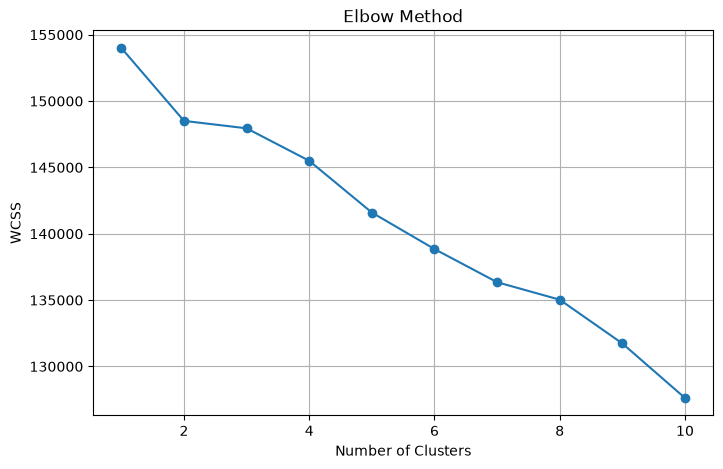

In [24]:
# ============================================
# Plot Elbow Curve
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [25]:
# ============================================
# Print WCSS Values
# ============================================

for i, value in enumerate(wcss, start=1):
    print(f"K = {i} --> WCSS = {value:.2f}")

K = 1 --> WCSS = 154000.00
K = 2 --> WCSS = 148506.99
K = 3 --> WCSS = 147946.87
K = 4 --> WCSS = 145497.19
K = 5 --> WCSS = 141597.78
K = 6 --> WCSS = 138846.39
K = 7 --> WCSS = 136347.56
K = 8 --> WCSS = 135028.25
K = 9 --> WCSS = 131730.04
K = 10 --> WCSS = 127619.47


In [26]:
# ============================================
# Silhouette Score
# ============================================

from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, labels)

    scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.3537
K = 3 | Silhouette Score = 0.0368
K = 4 | Silhouette Score = 0.0871
K = 5 | Silhouette Score = 0.0312
K = 6 | Silhouette Score = 0.0228
K = 7 | Silhouette Score = 0.0785
K = 8 | Silhouette Score = 0.0656
K = 9 | Silhouette Score = 0.0488
K = 10 | Silhouette Score = 0.0380


# K-Means Clustering

In [27]:
# ============================================
# Train Final KMeans Model
# ============================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

print("KMeans Model Trained Successfully.")

KMeans Model Trained Successfully.


In [28]:
buyer_df["Cluster"] = clusters

buyer_df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_properties,total_investment,avg_property_price,avg_property_area,Cluster
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000,0
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000,0
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000,0
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333,0
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154,0


In [29]:
buyer_df["Cluster"].value_counts().sort_index()

Cluster
0    1039
1     916
2      25
3      20
Name: count, dtype: int64

In [30]:
buyer_df["Cluster"] = clusters

buyer_df["Cluster"].value_counts().sort_index()

Cluster
0    1039
1     916
2      25
3      20
Name: count, dtype: int64

In [31]:
model_df["Cluster"] = clusters

model_df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,age,total_properties,total_investment,avg_property_price,avg_property_area,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA,region_Arizona,region_Baja California,region_Bavaria,region_Berlin,region_British Columbia,region_Brittany,region_Brussels,region_California,region_Capital Region,region_Central Denmark,region_Colorado,region_England,region_Flanders,region_Florida,region_Georgia,region_Hamburg,region_Hesse,region_Ile-de-France,region_Jalisco,region_Kansas,region_Krasnodar Krai,region_Manitoba,region_Mexico City,region_Moscow Oblast,region_Nevada,region_New South Wales,region_New York,region_Normandy,region_North Denmark,region_North Rhine-Westphalia,region_Northern Ireland,region_Novosibirsk,region_Nuevo Leon,region_Occitanie,region_Ohio,region_Ontario,region_Oregon,region_Provence,region_Puebla,region_Quebec,region_Queensland,region_Saint Petersburg,region_Scotland,region_South Australia,region_Southern Denmark,region_Tatarstan,region_Texas,region_Utah,region_Victoria,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,referral_channel_Client,referral_channel_Website,Cluster
0,1,0,0,4,1,58,4,1246764.72,311691.180000,983.885000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,1,0,1,0,63,5,1841095.93,368219.186000,1187.942000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,1,0,4,1,67,5,1661457.59,332291.518000,1058.110000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,1,0,5,0,66,6,1608263.51,268043.918333,937.103333,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,1,1,5,0,50,13,3653385.38,281029.644615,927.296154,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [32]:
model_df["Cluster"].value_counts()

Cluster
0    1039
1     916
2      25
3      20
Name: count, dtype: int64

In [33]:
buyer_df["Cluster"] = clusters

buyer_df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_properties,total_investment,avg_property_price,avg_property_area,Cluster
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000,0
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000,0
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000,0
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333,0
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154,0


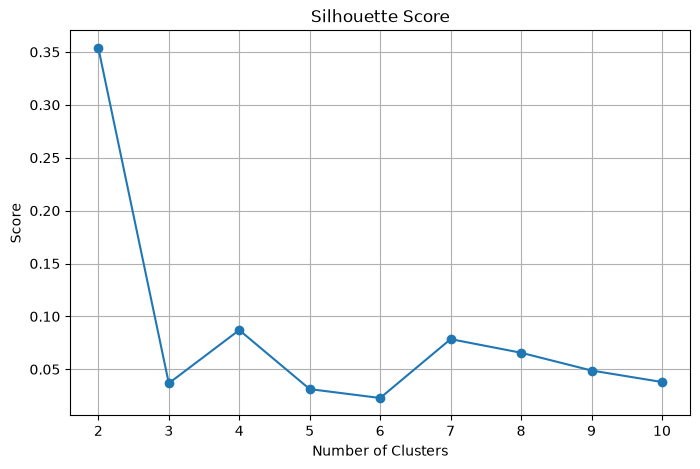

In [34]:
# ============================================
# Plot Silhouette Scores
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Score")

plt.grid(True)

plt.show()

# Cluster Profiling

## Objective

Analyze each cluster based on:

- Age
- Total Investment
- Total Properties
- Average Property Price
- Average Property Area
- Satisfaction Score

This helps identify meaningful buyer segments for business decision-making.

In [35]:
# ============================================
# Cluster Size
# ============================================

buyer_df["Cluster"].value_counts().sort_index()

Cluster
0    1039
1     916
2      25
3      20
Name: count, dtype: int64

In [36]:
# ============================================
# Cluster Summary
# ============================================

cluster_summary = buyer_df.groupby("Cluster")[
    [
        "age",
        "total_properties",
        "total_investment",
        "avg_property_price",
        "avg_property_area",
        "satisfaction_score"
    ]
].mean()

cluster_summary.round(2)

,age,total_properties,total_investment,avg_property_price,avg_property_area,satisfaction_score
Cluster,,,,,,
0,56.24,3.82,1450898.27,386050.18,1269.55,3.06
1,55.08,3.46,1041124.88,302668.71,1008.60,3.00
2,53.12,3.88,1365332.32,351157.32,1150.79,2.80
3,55.30,3.65,1273197.59,352515.38,1162.13,3.05


In [37]:
# ============================================
# Save Cluster Summary
# ============================================

cluster_summary.to_csv(
    "../outputs/cluster_summary.csv"
)

print("Cluster Summary Saved Successfully.")

Cluster Summary Saved Successfully.


# Cluster Distribution

## Objective

Visualize the number of buyers present in each cluster to understand the distribution of buyer segments.

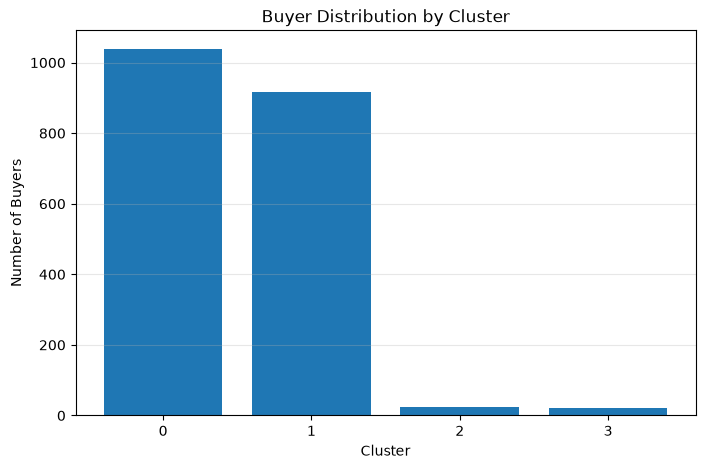

In [38]:
# ============================================
# Cluster Distribution
# ============================================

import matplotlib.pyplot as plt

cluster_counts = buyer_df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Buyer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Buyers")

plt.grid(axis="y", alpha=0.3)

plt.show()

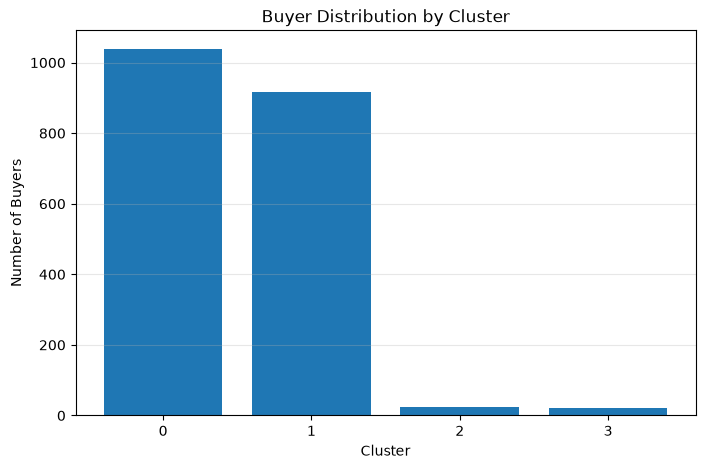

Cluster Distribution Plot Saved Successfully.


In [39]:
# ============================================
# Save Cluster Distribution Plot
# ============================================

plt.figure(figsize=(8,5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Buyer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Buyers")

plt.grid(axis="y", alpha=0.3)

plt.savefig("../outputs/cluster_distribution.png", dpi=300)

plt.show()

print("Cluster Distribution Plot Saved Successfully.")

# Hierarchical Clustering

## Objective

Perform Hierarchical Clustering to compare the clustering structure with the K-Means algorithm and validate buyer segmentation.

In [40]:
# ============================================
# Import Required Libraries
# ============================================

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [41]:
# ============================================
# Create Linkage Matrix
# ============================================

linked = linkage(
    scaled_df,
    method="ward"
)

print("Linkage Matrix Created Successfully.")

Linkage Matrix Created Successfully.


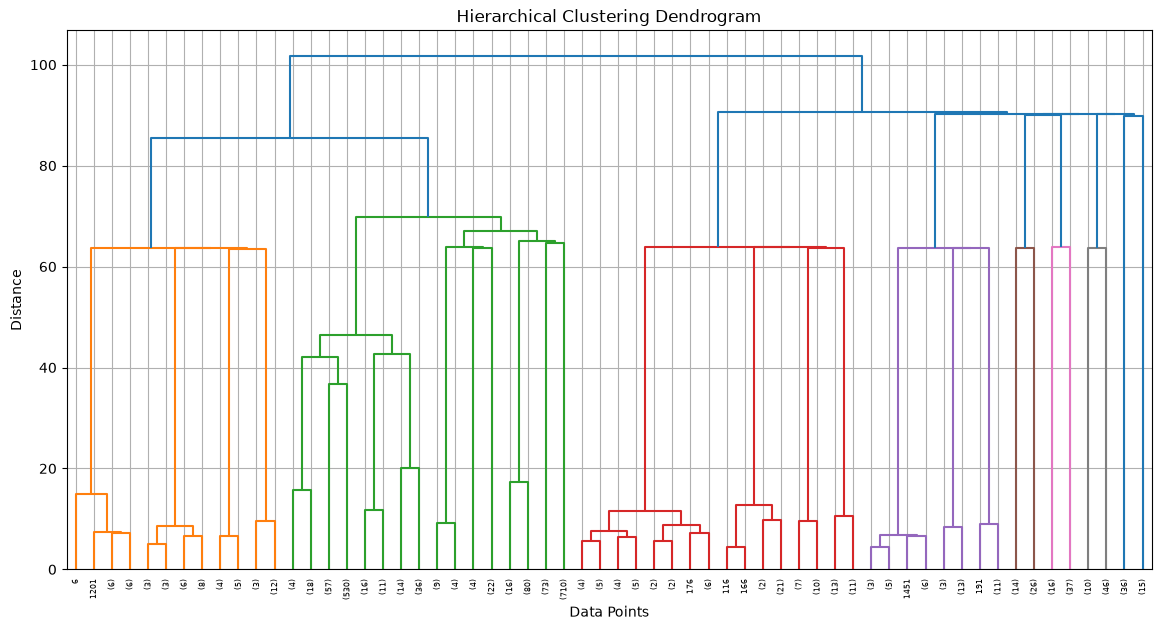

In [42]:
# ============================================
# Plot Dendrogram
# ============================================

plt.figure(figsize=(14,7))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.grid(True)

plt.show()

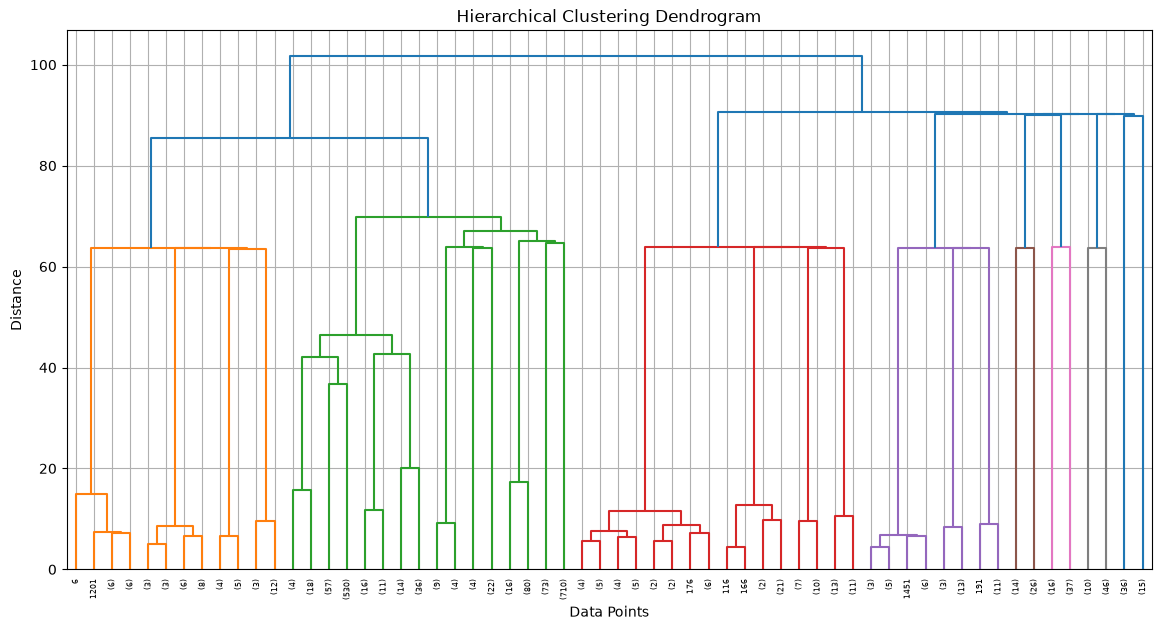

Dendrogram Saved Successfully.


In [43]:
# ============================================
# Save Dendrogram
# ============================================

plt.figure(figsize=(14,7))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.grid(True)

plt.savefig("../outputs/hierarchical_dendrogram.png", dpi=300)

plt.show()

print("Dendrogram Saved Successfully.")

# Business Intelligence

## Objective

Interpret each cluster using buyer demographics, investment behavior, financing patterns, and customer satisfaction.

The objective is to transform machine learning clusters into meaningful business buyer personas.

In [44]:
# ============================================
# Cluster-wise Summary Statistics
# ============================================

cluster_summary = buyer_df.groupby("Cluster").agg({

    "age":"mean",

    "total_properties":"mean",

    "total_investment":"mean",

    "avg_property_price":"mean",

    "avg_property_area":"mean",

    "satisfaction_score":"mean"

}).round(2)

cluster_summary

,age,total_properties,total_investment,avg_property_price,avg_property_area,satisfaction_score
Cluster,,,,,,
0,56.24,3.82,1450898.27,386050.18,1269.55,3.06
1,55.08,3.46,1041124.88,302668.71,1008.60,3.00
2,53.12,3.88,1365332.32,351157.32,1150.79,2.80
3,55.30,3.65,1273197.59,352515.38,1162.13,3.05


In [45]:
cluster_summary.T

Cluster,0,1,2,3
age,56.24,55.08,53.12,55.30
total_properties,3.82,3.46,3.88,3.65
total_investment,1450898.27,1041124.88,1365332.32,1273197.59
avg_property_price,386050.18,302668.71,351157.32,352515.38
avg_property_area,1269.55,1008.60,1150.79,1162.13
satisfaction_score,3.06,3.00,2.80,3.05


In [46]:
cluster_summary.describe()

,age,total_properties,total_investment,avg_property_price,avg_property_area,satisfaction_score
count,4.000000,4.000000,4.000000e+00,4.000000,4.000000,4.000000
mean,54.935000,3.702500,1.282638e+06,348097.897500,1147.767500,2.977500
std,1.310407,0.188746,1.766046e+05,34317.444745,107.104291,0.121209
min,53.120000,3.460000,1.041125e+06,302668.710000,1008.600000,2.800000
25%,54.590000,3.602500,1.215179e+06,339035.167500,1115.242500,2.950000
50%,55.190000,3.735000,1.319265e+06,351836.350000,1156.460000,3.025000
75%,55.535000,3.835000,1.386724e+06,360899.080000,1188.985000,3.052500
max,56.240000,3.880000,1.450898e+06,386050.180000,1269.550000,3.060000


In [47]:
cluster_summary.to_csv(
    "../outputs/cluster_summary.csv"
)

print("Cluster Summary Saved Successfully.")

Cluster Summary Saved Successfully.


# Cluster-wise Categorical Analysis

## Objective

Analyze buyer categories across different clusters to understand behavioral differences.

In [48]:
# ============================================
# Client Type by Cluster
# ============================================

pd.crosstab(
    buyer_df["Cluster"],
    buyer_df["client_type"]
)

client_type,Company,Individual
Cluster,,
0,52,987
1,49,867
2,2,23
3,0,20


In [49]:
# ============================================
# Gender by Cluster
# ============================================

pd.crosstab(
    buyer_df["Cluster"],
    buyer_df["gender"]
)

gender,F,M
Cluster,,
0,492,547
1,479,437
2,9,16
3,8,12


In [50]:
# ============================================
# Loan Applied by Cluster
# ============================================

pd.crosstab(
    buyer_df["Cluster"],
    buyer_df["loan_applied"]
)

loan_applied,No,Yes
Cluster,,
0,671,368
1,562,354
2,17,8
3,14,6


In [51]:
# ============================================
# Acquisition Purpose by Cluster
# ============================================

pd.crosstab(
    buyer_df["Cluster"],
    buyer_df["acquisition_purpose"]
)

acquisition_purpose,Home,Investment
Cluster,,
0,745,294
1,606,310
2,17,8
3,17,3


In [52]:
# ============================================
# Referral Channel by Cluster
# ============================================

pd.crosstab(
    buyer_df["Cluster"],
    buyer_df["referral_channel"]
)

referral_channel,Agency,Client,Website
Cluster,,,
0,357,95,587
1,331,97,488
2,6,0,19
3,11,0,9


# Cluster Labeling

## Objective

Assign meaningful business names to each machine learning cluster for better business understanding and dashboard visualization.

In [53]:
buyer_df["Cluster"].value_counts().sort_index()

Cluster
0    1039
1     916
2      25
3      20
Name: count, dtype: int64

In [54]:
# ============================================
# Average Values by Cluster
# ============================================

cluster_summary = buyer_df.groupby("Cluster")[[
    "age",
    "total_properties",
    "total_investment",
    "avg_property_price",
    "avg_property_area",
    "satisfaction_score"
]].mean().round(2)

cluster_summary

,age,total_properties,total_investment,avg_property_price,avg_property_area,satisfaction_score
Cluster,,,,,,
0,56.24,3.82,1450898.27,386050.18,1269.55,3.06
1,55.08,3.46,1041124.88,302668.71,1008.60,3.00
2,53.12,3.88,1365332.32,351157.32,1150.79,2.80
3,55.30,3.65,1273197.59,352515.38,1162.13,3.05


In [55]:
print(kmeans.n_clusters)

4


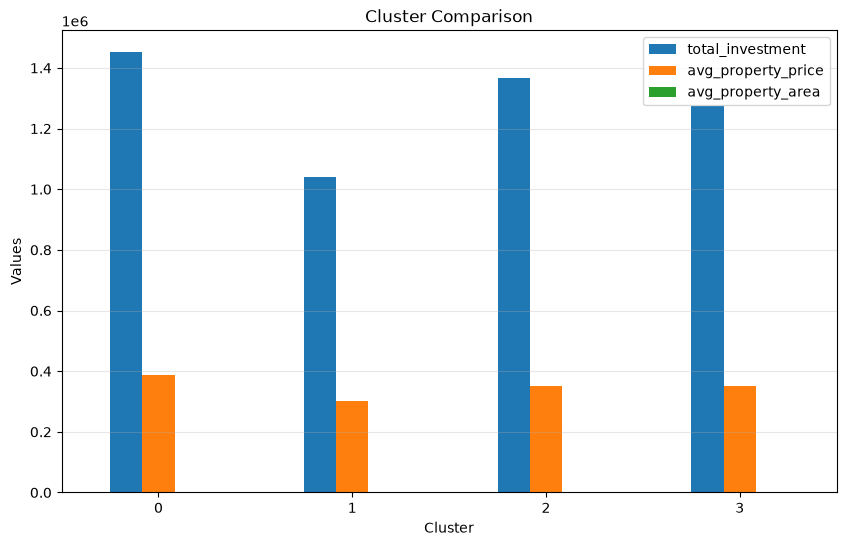

In [56]:
import matplotlib.pyplot as plt

cluster_summary[[
    "total_investment",
    "avg_property_price",
    "avg_property_area"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cluster Comparison")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Cluster Interpretation

Objective:

Interpret each cluster based on customer demographics,
investment behavior, property ownership,
and satisfaction level.

In [57]:
cluster_summary

,age,total_properties,total_investment,avg_property_price,avg_property_area,satisfaction_score
Cluster,,,,,,
0,56.24,3.82,1450898.27,386050.18,1269.55,3.06
1,55.08,3.46,1041124.88,302668.71,1008.60,3.00
2,53.12,3.88,1365332.32,351157.32,1150.79,2.80
3,55.30,3.65,1273197.59,352515.38,1162.13,3.05


In [58]:
cluster_size = buyer_df["Cluster"].value_counts().sort_index()

cluster_size

Cluster
0    1039
1     916
2      25
3      20
Name: count, dtype: int64

In [59]:
cluster_percentage = (
    buyer_df["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

cluster_percentage

Cluster
0    51.95
1    45.80
2     1.25
3     1.00
Name: proportion, dtype: float64

In [60]:
summary = cluster_summary.copy()

summary["buyers"] = cluster_size

summary["percentage"] = cluster_percentage

summary

,age,total_properties,total_investment,avg_property_price,avg_property_area,satisfaction_score,buyers,percentage
Cluster,,,,,,,,
0,56.24,3.82,1450898.27,386050.18,1269.55,3.06,1039,51.95
1,55.08,3.46,1041124.88,302668.71,1008.60,3.00,916,45.80
2,53.12,3.88,1365332.32,351157.32,1150.79,2.80,25,1.25
3,55.30,3.65,1273197.59,352515.38,1162.13,3.05,20,1.00


In [61]:
summary.to_csv(
    "../outputs/cluster_business_summary.csv",
    index=True
)

print("Business Summary Saved Successfully.")

Business Summary Saved Successfully.


In [62]:
persona = {
    0: "Premium Buyers",
    1: "Budget Buyers",
    2: "Elite Investors",
    3: "Corporate Investors"
}

buyer_df["Buyer_Persona"] = buyer_df["Cluster"].map(persona)

In [63]:
buyer_df[["Cluster","Buyer_Persona"]].head(15)

,Cluster,Buyer_Persona
0,0,Premium Buyers
1,0,Premium Buyers
2,0,Premium Buyers
3,0,Premium Buyers
4,0,Premium Buyers
5,0,Premium Buyers
6,0,Premium Buyers
7,0,Premium Buyers
8,0,Premium Buyers
9,0,Premium Buyers


In [64]:
buyer_df.to_csv(
    "../data/processed/final_buyer_dataset.csv",
    index=False
)

print("Final Buyer Dataset Saved Successfully.")

Final Buyer Dataset Saved Successfully.


In [65]:
buyer_df.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'age',
       'total_properties', 'total_investment', 'avg_property_price',
       'avg_property_area', 'Cluster', 'Buyer_Persona'],
      dtype='str')

In [66]:
%who

AgglomerativeClustering	 KMeans	 LabelEncoder	 StandardScaler	 binary_columns	 buyer_df	 categorical_cols	 cluster_counts	 cluster_percentage	 
cluster_size	 cluster_summary	 clusters	 col	 dendrogram	 i	 k	 kmeans	 label_encoder	 
labels	 linkage	 linked	 model	 model_df	 np	 one_hot_columns	 pd	 persona	 
plt	 scaled_data	 scaled_df	 scaler	 score	 scores	 silhouette_score	 summary	 value	 
wcss	 
